In [2]:
!pip install ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [3]:
import re
import html
import unicodedata

from bs4 import BeautifulSoup
from ftfy import fix_text


def light_clean_text(text):
    if text is None:
        return ""

    text = str(text)
    text = fix_text(text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = re.sub(r"\bect\b", "", text)
    text = re.sub(r"[\u200B-\u200D\uFEFF]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [4]:
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd


def load_spam_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="latin1")

    extra_cols = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]
    for col in extra_cols:
        if col not in df.columns:
            df[col] = ""

    df["text"] = (
        df["v2"].fillna("").astype(str) + " " +
        df["Unnamed: 2"].fillna("").astype(str) + " " +
        df["Unnamed: 3"].fillna("").astype(str) + " " +
        df["Unnamed: 4"].fillna("").astype(str)
    )

    df = df.rename(columns={"v1": "label"})
    return df[["label", "text"]]


def load_dataset_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="latin1")
    df = df.rename(columns={"text_type": "label", "text": "text"})
    return df[["label", "text"]]


def make_dataset(spam_csv: str, dataset_csv: str, output_path: str) -> None:
    df1 = load_spam_csv(spam_csv)
    df2 = load_dataset_csv(dataset_csv)

    df = pd.concat([df1, df2], ignore_index=True)

    df["text"] = df["text"].fillna("").astype(str)
    df["cleaned_text"] = df["text"].apply(light_clean_text)

    df = df.drop_duplicates(subset=["label", "cleaned_text"]).reset_index(drop=True)

    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output, index=False)

    print(f"Saved cleaned dataset to {output}")
    print(f"Rows: {len(df)}")
    print(df["label"].value_counts())

file1_path = 'spam.csv'
file2_path = 'dataset.csv'

make_dataset(spam_csv=file1_path, dataset_csv=file2_path, output_path='combined_dataset.csv',
    )


Saved cleaned dataset to combined_dataset.csv
Rows: 25062
label
ham     18435
spam     6627
Name: count, dtype: int64


In [7]:
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split


def split_dataset(
    input_path: str,
    train_output: str,
    test_output: str,
    test_size: float = 0.2,
    random_state: int = 42,
) -> None:
    df = pd.read_csv(input_path)

    required_cols = {"label", "text", "cleaned_text"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["label"] = (
        df["label"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    df = df[df["label"].isin(["ham", "spam"])].copy()

    df["label_num"] = (df["label"] == "spam").astype(int)

    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df["label_num"],
    )

    train_out = Path(train_output)
    test_out = Path(test_output)
    train_out.parent.mkdir(parents=True, exist_ok=True)
    test_out.parent.mkdir(parents=True, exist_ok=True)

    train_df.to_csv(train_out, index=False)
    test_df.to_csv(test_out, index=False)

    print(f"Train saved to {train_out} with {len(train_df)} rows")
    print(f"Test saved to {test_out} with {len(test_df)} rows")

    print("\nTrain label distribution:")
    print(train_df["label"].value_counts(normalize=True))

    print("\nTest label distribution:")
    print(test_df["label"].value_counts(normalize=True))



split_dataset(input_path='combined_dataset.csv',train_output='train.csv',test_output='test.csv', test_size=0.2,random_state=42)


Train saved to train.csv with 20049 rows
Test saved to test.csv with 5013 rows

Train label distribution:
label
ham     0.735598
spam    0.264402
Name: proportion, dtype: float64

Test label distribution:
label
ham     0.735488
spam    0.264512
Name: proportion, dtype: float64


In [11]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [12]:
from __future__ import annotations

import argparse
import json
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline


def train_baseline(
    train_path: str,
    test_path: str,
    model_output: str,
    metrics_output: str,
    experiment_name: str = "Spam_Classification_Baseline",
) -> None:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    X_train = train_df["cleaned_text"].astype(str).tolist()
    y_train = train_df["label_num"].astype(int).tolist()
    X_test = test_df["cleaned_text"].astype(str).tolist()
    y_test = test_df["label_num"].astype(int).tolist()

    model_output_path = Path(model_output)
    metrics_output_path = Path(metrics_output)
    model_output_path.parent.mkdir(parents=True, exist_ok=True)
    metrics_output_path.parent.mkdir(parents=True, exist_ok=True)

    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name="TFIDF_LogisticRegression"):
        pipe = Pipeline([
            ("tfidf", TfidfVectorizer(max_features=5000)),
            ("clf", LogisticRegression(max_iter=1000)),
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        metrics = {
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "fpr": float(fpr),
            "cm_tn": int(tn),
            "cm_fp": int(fp),
            "cm_fn": int(fn),
            "cm_tp": int(tp),
        }

        print("--- Baseline Metrics ---")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"False Positive Rate (FPR): {fpr:.4f}")
        print(f"Confusion Matrix:\n[[{tn}, {fp}]\n [{fn}, {tp}]]")

        mlflow.log_param("model", "LogisticRegression")
        mlflow.log_param("vectorizer", "TfidfVectorizer")
        mlflow.log_param("max_features", 5000)
        mlflow.log_param("max_iter", 1000)

        mlflow.log_metrics(metrics)

        joblib.dump(pipe, model_output_path)
        mlflow.sklearn.log_model(pipe, artifact_path="baseline_model")
        mlflow.log_artifact(str(model_output_path))

        with open(metrics_output_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, indent=2)
        mlflow.log_artifact(str(metrics_output_path))


train_baseline(
    train_path='train.csv',
    test_path='test.csv',
    model_output='model.joblib',
    metrics_output='baseline_metrics.json',
    experiment_name='Spam_Classification_Baseline',
)


2026/04/28 11:43:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/28 11:43:13 INFO mlflow.store.db.utils: Updating database tables
2026/04/28 11:43:19 INFO mlflow.tracking.fluent: Experiment with name 'Spam_Classification_Baseline' does not exist. Creating a new experiment.


--- Baseline Metrics ---
Precision: 0.9506
Recall: 0.8560
F1 Score: 0.9008
False Positive Rate (FPR): 0.0160
Confusion Matrix:
[[3628, 59]
 [191, 1135]]


2026/04/28 11:43:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 11:43:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [16]:
from __future__ import annotations

import argparse
import json
from pathlib import Path

import mlflow
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


def extract_baseline_feature_importance(
    train_path: str,
    output_csv: str,
    output_json: str,
    experiment_name: str = "Spam_Classification_Baseline",
) -> None:
    train_df = pd.read_csv(train_path)

    X_train = train_df["cleaned_text"].astype(str).tolist()
    y_train = train_df["label_num"].astype(int).tolist()

    output_csv_path = Path(output_csv)
    output_json_path = Path(output_json)

    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    output_json_path.parent.mkdir(parents=True, exist_ok=True)

    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name="TFIDF_LogisticRegression_FeatureImportance"):
        vectorizer = TfidfVectorizer(max_features=5000)
        X_train_tfidf = vectorizer.fit_transform(X_train)

        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train_tfidf, y_train)

        feature_names = vectorizer.get_feature_names_out()
        coefficients = clf.coef_[0]

        feature_importance = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coefficients,
        })

        feature_importance["abs_coefficient"] = feature_importance["coefficient"].abs()
        feature_importance = feature_importance.sort_values(
            by="abs_coefficient",
            ascending=False,
        ).reset_index(drop=True)

        top_overall = feature_importance.head(10)
        top_spam = (
            feature_importance[feature_importance["coefficient"] > 0]
            .sort_values(by="coefficient", ascending=False)
            .head(10)
        )
        top_ham = (
            feature_importance[feature_importance["coefficient"] < 0]
            .sort_values(by="coefficient", ascending=True)
            .head(10)
        )

        print("\n--- Top 10 Most Important Features Overall ---")
        print(top_overall)

        print("\n--- Top 10 Features Indicating Spam ---")
        print(top_spam)

        print("\n--- Top 10 Features Indicating Ham ---")
        print(top_ham)

        feature_importance.to_csv(output_csv_path, index=False)

        results = {
            "top_overall": top_overall.to_dict(orient="records"),
            "top_spam": top_spam.to_dict(orient="records"),
            "top_ham": top_ham.to_dict(orient="records"),
        }

        with open(output_json_path, "w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)

        mlflow.log_param("model", "LogisticRegression")
        mlflow.log_param("vectorizer", "TfidfVectorizer")
        mlflow.log_param("max_features", 5000)
        mlflow.log_param("max_iter", 1000)

        mlflow.log_artifact(str(output_csv_path))
        mlflow.log_artifact(str(output_json_path))

        print(f"\nSaved full feature importance CSV to: {output_csv_path}")
        print(f"Saved top feature summary JSON to: {output_json_path}")




extract_baseline_feature_importance(
      train_path='train.csv',
      output_csv='baseline_feature_importance.csv',
      output_json='baseline_feature_importance.json',
      experiment_name="Spam_Classification_Baseline",
  )


--- Top 10 Most Important Features Overall ---
  feature  coefficient  abs_coefficient
0   enron    -6.276678         6.276678
1   vince    -5.630692         5.630692
2    earn     4.587886         4.587886
3    free     4.373892         4.373892
4    join     4.314173         4.314173
5      dm     4.092741         4.092741
6     sms     4.085648         4.085648
7    your     3.778151         3.778151
8  profit     3.777398         3.777398
9      rs     3.626259         3.626259

--- Top 10 Features Indicating Spam ---
      feature  coefficient  abs_coefficient
2        earn     4.587886         4.587886
3        free     4.373892         4.373892
4        join     4.314173         4.314173
5          dm     4.092741         4.092741
6         sms     4.085648         4.085648
7        your     3.778151         3.778151
8      profit     3.777398         3.777398
9          rs     3.626259         3.626259
10  hyperlink     3.625040         3.625040
11      noida     3.591226     

# EDA

In [8]:
df_spam = pd.read_csv('combined_dataset.csv')

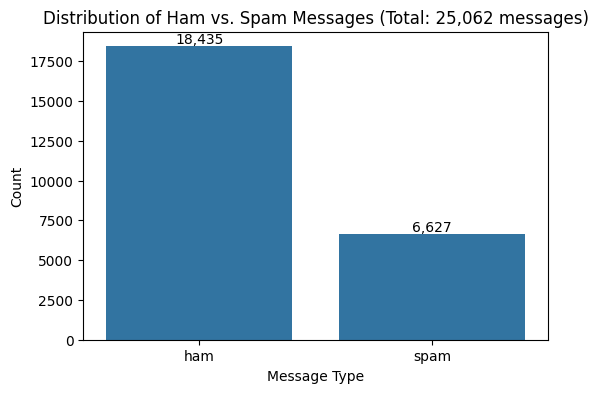

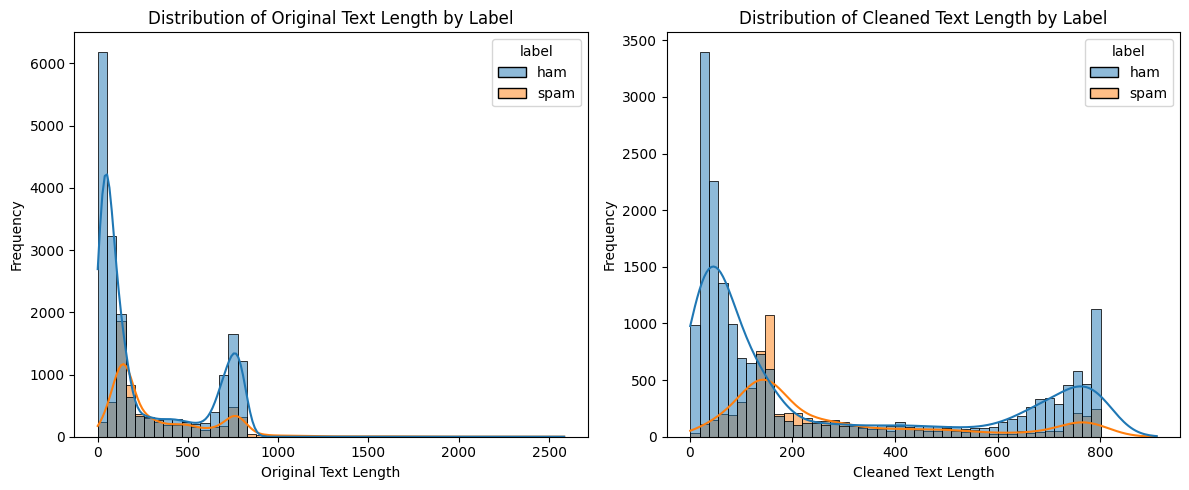

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of 'label' (ham vs. spam)
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df_spam)
plt.title(f'Distribution of Ham vs. Spam Messages (Total: {len(df_spam):,} messages)')
plt.xlabel('Message Type')
plt.ylabel('Count')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')
plt.show()

# 2. Distribution of message lengths
# Calculate length of original and cleaned text
df_spam['original_text_length'] = df_spam['text'].apply(len)
df_spam['cleaned_text_length'] = df_spam['cleaned_text'].apply(len)

plt.figure(figsize=(12, 5))

# Original text length distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df_spam, x='original_text_length', hue='label', kde=True, bins=50)
plt.title('Distribution of Original Text Length by Label')
plt.xlabel('Original Text Length')
plt.ylabel('Frequency')

# Cleaned text length distribution
plt.subplot(1, 2, 2)
sns.histplot(data=df_spam, x='cleaned_text_length', hue='label', kde=True, bins=50)
plt.title('Distribution of Cleaned Text Length by Label')
plt.xlabel('Cleaned Text Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

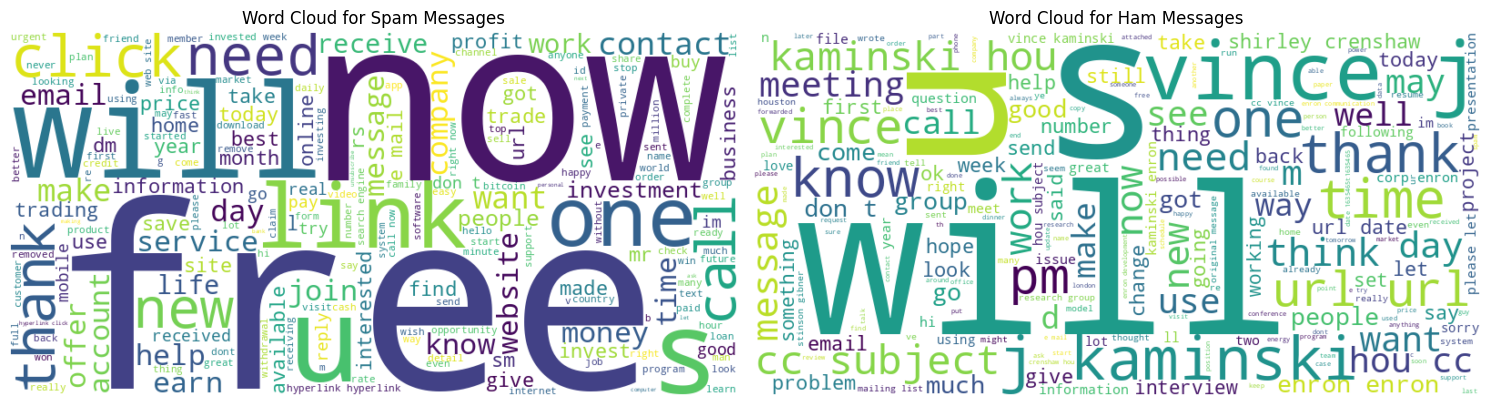

In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Install wordcloud if not already installed
!pip install wordcloud

# Separate spam and ham messages
spam_messages = df_spam[df_spam['label'] == 'spam']['cleaned_text']
ham_messages = df_spam[df_spam['label'] == 'ham']['cleaned_text']

# Concatenate all spam messages into a single string
spam_text = " ".join(spam_messages)

# Concatenate all ham messages into a single string
ham_text = " ".join(ham_messages)

# Generate Word Cloud for Spam
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

# Generate Word Cloud for Ham
wordcloud_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

# Plotting the Word Clouds
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Word Cloud for Spam Messages')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Word Cloud for Ham Messages')
plt.axis('off')

plt.tight_layout()
plt.show()

#### Extraction of spam data (validation for manual labelling)

In [ ]:
# Extract only spam messages
df_spam_only = df_spam[df_spam['label'] == 'spam'].copy()

# Prepare features (cleaned_text) and labels (label_num) for spam only
X_spam = df_spam_only['cleaned_text'].astype(str).values
y_spam = df_spam_only['label'].values # Using existing numeric label for split

# Split spam messages into train and validation sets (e.g., 80/20% split)
X_spam_train, X_spam_val, y_spam_train, y_spam_val = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42, stratify=y_spam
)

print(f"Total spam messages: {len(df_spam_only)}")
print(f"Spam training samples: {len(X_spam_train)}")
print(f"Spam validation samples: {len(X_spam_val)}")

Total spam messages: 642
Spam training samples: 513
Spam validation samples: 129


In [ ]:
df_spam_val_export = pd.DataFrame({'text': X_spam_val, 'label': y_spam_val})
df_spam_val_export.to_csv('spam_validation_samples.csv', index=False)
print("Spam validation samples saved to 'spam_validation_samples.csv'")

Spam validation samples saved to 'spam_validation_samples.csv'
